In [ ]:
#Hourly observations

import stormstat

df = stormstat.load_station_csv(
    "../data/sample_data.csv",
    wind_speed_col="wind_speed",
    wind_dir_col="wind_dir",
)
print(f"Loaded {len(df):,} hourly observations")
df.head()

Loaded 8,760 hourly observations


,temp_c,dewpoint_c,wind_speed,wind_dir,precip_mm
datetime,,,,,
2023-01-01 00:00:00,-8.4,-19.7,4.20,232.6,0.86
2023-01-01 01:00:00,-6.9,-12.4,0.94,289.3,0.00
2023-01-01 02:00:00,-7.2,-12.8,2.54,13.8,0.00
2023-01-01 03:00:00,-10.3,-20.3,5.87,250.3,0.00
2023-01-01 04:00:00,-9.7,-23.6,0.92,282.4,0.00


In [ ]:
# Monthly temperature summary

summary = stormstat.monthly_summary(df, variable="temp_c")
summary

mean   max   min   std  count
year month                                
2023 1      -3.87   9.2 -17.4  5.39    737
     2      -2.25  10.4 -13.2  5.43    665
     3       2.24  15.6 -12.6  5.60    740
     4       9.24  22.3  -5.0  5.66    716
     5      16.33  30.3   2.9  5.72    742
     6      21.70  34.5   7.8  5.56    716
     7      23.82  35.9  11.9  5.25    741
     8      22.30  35.4   9.7  5.44    739
     9      17.41  31.4   2.1  5.61    717
     10     10.55  24.4  -3.0  5.68    743
     11      3.50  18.0 -11.6  5.64    718
     12     -1.59  11.8 -16.8  5.48    743

In [6]:
# Heat index examples

import numpy as np

temps = [25, 33, 37, 42]
humidity = [53, 67, 72, 85]

for t, rh in zip(temps, humidity):
    hi = stormstat.heat_index(t, rh)
    print(f"{t}°C at {rh}% RH → Heat Index: {float(hi):.1f}°C")

25°C at 53% RH → Heat Index: 24.9°C
33°C at 67% RH → Heat Index: 34.1°C
37°C at 72% RH → Heat Index: 38.6°C
42°C at 85% RH → Heat Index: 44.5°C


In [7]:
# Wind statistics

stats = stormstat.wind_stats(df["wind_speed"], wind_dir=df["wind_dir"])

for k, v in stats.items():
    if k == "dir_pct":
        print("Direction breakdown:")
        for sector, pct in sorted(v.items(), key=lambda x: -x[1])[:4]:
            print(f"  {sector}: {pct:.1f}%")
    else:
        print(f"{k}: {v}")

mean: 3.97
max: 13.19
std: 2.07
calm_pct: 1.07
p50: 3.71
p90: 6.79
p95: 7.73
dominant_dir: W
Direction breakdown:
  W: 29.5%
  NW: 22.6%
  SW: 22.2%
  N: 10.2%


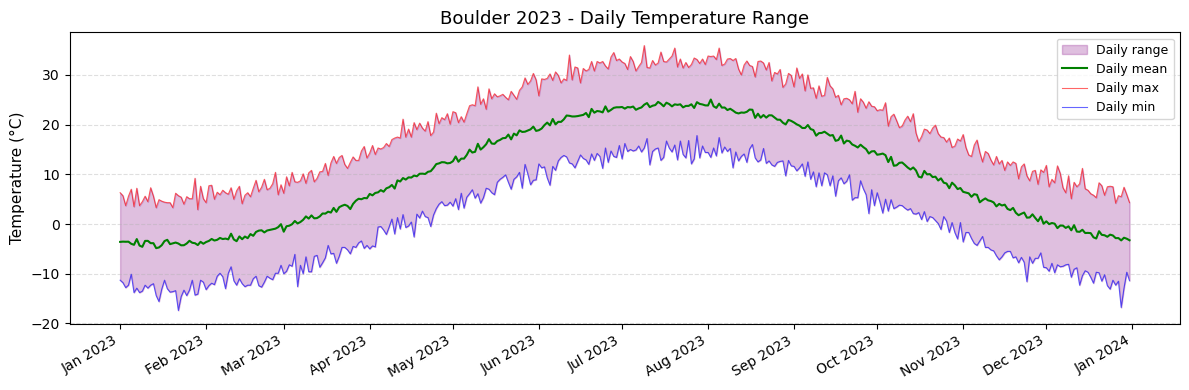

In [13]:
# Daily temperature plot

fig = stormstat.plot_temperature(df, title="Boulder 2023 - Daily Temperature Range")

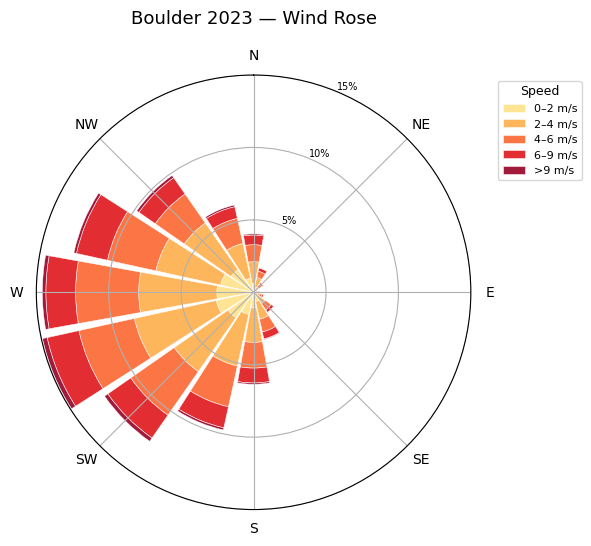

In [9]:
# Wind rose plot

fig = stormstat.plot_wind_rose(df["wind_speed"], df["wind_dir"],
                               title="Boulder 2023 — Wind Rose")